<a href="https://colab.research.google.com/github/adndrhmdn1/Tasks/blob/main/Tugas_PDAB_dataset_ecommerce_customer_churn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# *ANALISIS DATA ECOMMERCE CUSTOMER CHURN DENGAN NAIVE BAYES*

In [1]:
from google.colab import files
uploaded = files.upload()

Saving data_ecommerce_customer_churn.csv to data_ecommerce_customer_churn.csv


In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.naive_bayes import GaussianNB

import seaborn as sns
import matplotlib.pyplot as plt

# *Load Dataset*

In [3]:
df = pd.read_csv('data_ecommerce_customer_churn.csv')
print("5 Data Pertama:")
display(df.head())

5 Data Pertama:


,Tenure,WarehouseToHome,NumberOfDeviceRegistered,PreferedOrderCat,SatisfactionScore,MaritalStatus,NumberOfAddress,Complain,DaySinceLastOrder,CashbackAmount,Churn
0,15.0,29.0,4,Laptop & Accessory,3,Single,2,0,7.0,143.32,0
1,7.0,25.0,4,Mobile,1,Married,2,0,7.0,129.29,0
2,27.0,13.0,3,Laptop & Accessory,1,Married,5,0,7.0,168.54,0
3,20.0,25.0,4,Fashion,3,Divorced,7,0,NaN,230.27,0
4,30.0,15.0,4,Others,4,Single,8,0,8.0,322.17,0


Dataset ini berisi informasi pelanggan seperti Tenure, MaritalStatus, NumberofADdress, Complain, CashbackAmount, dan Churn. Variabel Churn bernilai:
0 = pelanggan tetap bertahan
1 = pelanggan keluar
Dari 5 data pertama yang muncul semuanya bernilai 0, artinya pelanggan tersebut tidak churn.

# *Informasi Data*

In [4]:
print("Ukuran Data :", df.shape)
print("\nInfo Data:")
print(df.info())

print("\nMissing Value:")
print(df.isnull().sum())

Ukuran Data : (3941, 11)

Info Data:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3941 entries, 0 to 3940
Data columns (total 11 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Tenure                    3747 non-null   float64
 1   WarehouseToHome           3772 non-null   float64
 2   NumberOfDeviceRegistered  3941 non-null   int64  
 3   PreferedOrderCat          3941 non-null   object 
 4   SatisfactionScore         3941 non-null   int64  
 5   MaritalStatus             3941 non-null   object 
 6   NumberOfAddress           3941 non-null   int64  
 7   Complain                  3941 non-null   int64  
 8   DaySinceLastOrder         3728 non-null   float64
 9   CashbackAmount            3941 non-null   float64
 10  Churn                     3941 non-null   int64  
dtypes: float64(4), int64(5), object(2)
memory usage: 338.8+ KB
None

Missing Value:
Tenure                      194
WarehouseToHome         

Pada output ini dapat terlihat bahwa jumlah pelanggan ada 3941 baris dan 11 kolom untuk jumlah variabelnya. Output info menunjukkan tipe data:
float64 = numerik pecahan
int64 = bilangan bulat
object = teks/kategori
Karena ada data kategorik, perlu dilakukan encoding sebelum modeling.
Terdapat data kosong pada:
Tenure = 194
WarehouseToHome = 169
DaySinceLastOrder = 213
Jika tidak diatasi, missing value dapat menyebabkan model error atau hasil kurang baik.

# *Handle Missing Value*

Isi numerik dengan media

In [5]:
for col in df.select_dtypes(include=np.number).columns:
    df[col].fillna(df[col].median(), inplace=True)

/tmp/ipykernel_13746/2155874100.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].median(), inplace=True)


Isi kategorik dengan modus

In [6]:
for col in df.select_dtypes(include='object').columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

/tmp/ipykernel_13746/3448830320.py:2: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df[col].fillna(df[col].mode()[0], inplace=True)


# *Encoding Data Kategorik*

In [7]:
le = LabelEncoder()

for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = le.fit_transform(df[col])

# *Pemisahan X dan Y*

In [8]:
X = df.drop('Churn', axis=1)
y = df['Churn']

# *Split Training dan Testing*

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# *Pembuatan Model Naive Bayes*

In [10]:
model = GaussianNB()
model.fit(X_train, y_train)

GaussianNB()

# *Prediksi*

In [11]:
y_pred = model.predict(X_test)

# *Evaluasi Model*

In [12]:
acc = accuracy_score(y_test, y_pred)

print("Akurasi Model :", round(acc*100,2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Akurasi Model : 85.8 %

Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.91      0.91       654
           1       0.58      0.59      0.59       135

    accuracy                           0.86       789
   macro avg       0.75      0.75      0.75       789
weighted avg       0.86      0.86      0.86       789



Pada hasil output dari seluruh data testing, model mampu memprediksi akurasi model = 85.8% data dengan benar. Nilai ini menunjukkan peforma model yang cukup baik.
Pada Kelas 0 (tidak churn) nilai precision 0.92 yang artinya prediksi tidak churn tepat dan nilai recall 0.91 artinya hampir semua pelanggan tidak churn berhasil dikenali. Sedangkan pada hasil Kelas 1 (churn) nilai precision 0.58 dan recall 0.59 artinya model masih cukup lemah mendeteksi pelanggan churn. Model lebih baik memprediksi pelanggan tidak churn daripada churn.

# *Confusion Matrix*

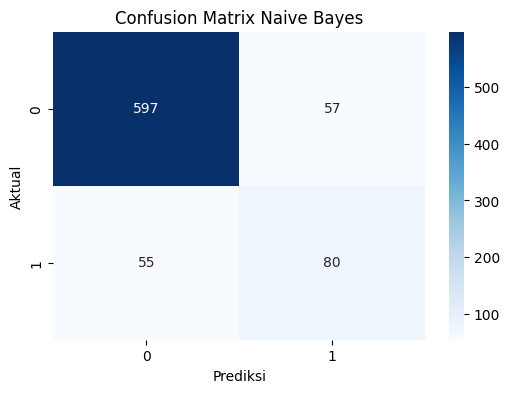

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix Naive Bayes")
plt.xlabel("Prediksi")
plt.ylabel("Aktual")
plt.show()

Prediksi benar:
597 pelanggan tidak churn diprediksi benar dan 80 pelanggan churn diprediksi benar.

Prediksi salah:
57 pelanggan tidak churn diprediksi churn dan 55 pelanggan churn diprediksi tidak churn.

# *Kesimpulan*

Berdasarkan seluruh hasil analisis yang telah dilakukan, dapat diketahui bahwa dataset yang digunakan terdiri atas 3.941 data pelanggan. Pada tahap awal pengolahan data ditemukan beberapa nilai yang hilang (missing value) pada sejumlah variabel, kemudian data tersebut berhasil ditangani melalui proses prepocessing sehingga dataset siap digunakan untuk pemodelan. Selanjutnya, penerapan metode naive bayes menghasilkan tingkat akurasi sebesar 85,85 yang menunjukkan bahwa model memiliki peforma yang cukup baik dalam melakukan klasifikasi data pelanggan. Model ini terbukti sangat baik dalam mengenali pelanggan yang tidak mengalami churn, namun kemampuan mdoel dalam mendeteksi pelanggan yang benar-benar churn masih perlu ditingkatkan agar hasil prediksi menjadi lebih optimal dan seimbang.